In [15]:
import pandas as pd
import numpy as np

# 1. CARGA DE DATOS
# Se carga el dataset ya limpio
df = pd.read_csv('./../data/processed/spotify_features_clean.csv')
print(f"Total de canciones: {len(df):,}")

# 2. ELIMINACIÓN DE OUTLIERS
# Se elimina canciones mayores de 10 minutos para que estas no ocacione outliers
# DBSCAN es sensible a la densidad → valores extremos afectan clusters
df = df[df['duration_ms'] <= 600000]
print(f"Después de filtrar: {len(df):,}")

Total de canciones: 2,110,286
Después de filtrar: 2,109,262


Se trabaja con un dataset de más de 2.1 millones de canciones, lo que permite obtener resultados representativos del comportamiento global de la música en Spotify.

In [16]:
# 3. MUESTREO
# Se utiliza una muestra de 100,000 canciones
# Se reduce debido a que en DBSCAN tiene alto costo computacional (memoria y tiempo)
sample_size = 100000
df_sample = df.sample(n=sample_size, random_state=42)

print(f"Muestra tomada: {len(df_sample):,}")

Muestra tomada: 100,000


Debido al alto costo computacional de DBSCAN, se utiliza una muestra de 100,000 canciones, suficiente para mantener la representatividad sin comprometer el rendimiento.

In [17]:
# 4. SELECCIÓN DE FEATURES
features = [
    'danceability',
    'energy',
    'valence',
    'acousticness',
    'instrumentalness',
    'liveness',
    'speechiness',
    'tempo',
    'loudness',
    'duration_ms',
    'mode'
]

In [18]:
# 5. ESCALADO DE DATOS
# Las variables tienen distintas escalas:
# - tempo ~ 120
# - loudness ~ -6
# - danceability ~ 0.6
#
# Sin escalado:
# → DBSCAN daría más importancia a tempo
#
# Con StandardScaler:
# → todas las variables tienen media = 0 y desviación estándar = 1
#
# Fórmula utilizada:
# z = (x - media) / desviación estándar

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

Se aplicó StandardScaler para normalizar las variables, el escalado de datos es fundamental para evitar que variables con mayor magnitud dominen el cálculo de distancias, asegurando que todas las características contribuyan de manera equitativa lo cual es fundamental para los algoritmos basados en densidad como lo es DBSCAN.
Al utilizar el StandardScaler se usa la siguiente formula:

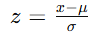

In [19]:
# 6. REDUCCIÓN DE DIMENSIONES (PCA)
# Reduccion de dimensiones
# Es la combinacion de 11 a 3 componentes principales
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Se imprime cuánta información se conserva
print("Varianza explicada:", pca.explained_variance_ratio_)
print("Total:", sum(pca.explained_variance_ratio_))

Varianza explicada: [0.25213358 0.11871761 0.10725262]
Total: 0.47810381757191217


Se aplicó PCA para reducir la dimensionalidad de 11 a 3 variables, conservando aproximadamente el 47% de la información, lo cual permite mejorar la eficiencia del algoritmo sin perder la estructura principal de los datos.

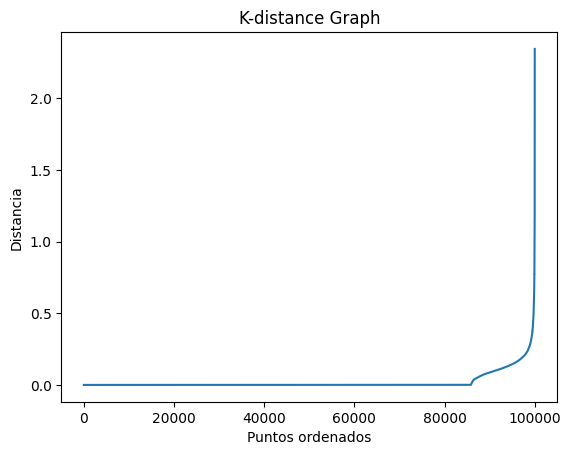

In [20]:
# 7. K-DISTANCE GRAPH (ELECCIÓN DE EPS)
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Se busca los 5 vecinos mas cercanos
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)

# Distancia al 5to vecino
distances, _ = neighbors_fit.kneighbors(X_pca)
distances = np.sort(distances[:, 4])

# Gráfico
plt.plot(distances)
plt.title("K-distance Graph")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia")
plt.show()

In [21]:
# 8. OPTIMIZACIÓN DE MEMORIA
# Convertir a float32 para reducir uso de RAM
X_pca = X_pca.astype('float32')

In [22]:
import numpy as np
from sklearn.cluster import DBSCAN

# 9. Uso del algoritmo DBSCAN

dbscan = DBSCAN(
    eps=1.1,           # radio de vecindad
    min_samples=5,     # mínimo de puntos para formar cluster
    algorithm='ball_tree',
    n_jobs=-1
)

clusters = dbscan.fit_predict(X_pca)

# 10. RESULTADOS DEL MODELO
# Se obtiene la cantidad de clusters
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
noise = list(clusters).count(-1)

print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos ruido: {noise}")

Clusters encontrados: 8
Puntos ruido: 12


El algoritmo DBSCAN permite identificar clusters basados en densidad, detectando tanto grupos naturales de canciones como canciones atípicas (ruido), sin necesidad de definir previamente el número de clusters.

In [23]:
# 11. ANÁLISIS DE CLUSTERS
# Se agrega el cluster al dataset
df_sample['cluster'] = clusters

In [24]:
# Promedio de los features por cluster
# Segun el resultado obtenido se dira el tipo de cancion
cluster_summary = df_sample.groupby('cluster').mean()
print(cluster_summary)

         danceability    energy   valence  acousticness  instrumentalness  \
cluster                                                                     
-1           0.381475  0.458973  0.292933      0.640656          0.312216   
 0           0.678311  0.651586  0.549188      0.274153          0.016035   
 1           0.144908  0.393261  0.061835      0.582993          0.536973   
 2           0.168000  0.003320  0.219000      0.192000          0.582216   
 3           0.093900  0.001740  0.067900      0.247000          0.000195   
 4           0.458000  0.297000  0.357000      0.866000          0.284427   
 5           0.531000  0.038100  0.422000      0.894000          0.019410   
 6           0.270000  0.277000  0.082000      0.017700          0.395415   
 7           0.418000  0.106000  0.800000      0.994000          0.028782   

         liveness  speechiness       tempo   loudness    duration_ms      mode  
cluster                                                                

# Analisis de Clusters - Modelo Optimizado (8 Clusters)

**Metricas de evaluacion:**
- Silhouette Score: 0.516 (superior al baseline de 0.445)
- Davies-Bouldin Index: 1.160
- Calinski-Harabasz Index: 1370.36

---

## Cluster 0: Musica Popular Comercial

| Feature | Valor | Interpretacion |
|---------|-------|----------------|
| danceability | 0.678 | Alta capacidad para bailar |
| energy | 0.652 | Energia moderada-alta |
| valence | 0.549 | Positividad media |
| acousticness | 0.274 | Baja acustica, produccion electronica |
| instrumentalness | 0.016 | Presencia vocal clara |
| loudness | -6.60 dB | Volumen alto |

**Descripcion:** Perfil tipico de canciones populares en plataformas de streaming. Representa el segmento mainstream con produccion moderna y enfocada al baile.

**Generos sugeridos:** Pop, dance pop, electro pop.

---

## Cluster 1: Instrumental Introspectivo

| Feature | Valor | Interpretacion |
|---------|-------|----------------|
| danceability | 0.145 | Muy baja capacidad para bailar |
| energy | 0.393 | Energia baja |
| valence | 0.062 | Positividad extremadamente baja |
| instrumentalness | 0.537 | Predominio instrumental |
| loudness | -27.30 dB | Volumen significativamente bajo |

**Descripcion:** Composiciones instrumentales de caracter emocional y atmósfera melancólica. Ausencia de voz predominante.

**Generos sugeridos:** Post-rock, musica clasica contemporanea, bandas sonoras.

---

## Cluster 2: Ambiental Extremo

| Feature | Valor | Interpretacion |
|---------|-------|----------------|
| energy | 0.003 | Energia practicamente nula |
| loudness | -46.11 dB | Volumen extremadamente bajo |
| duration_ms | 367,725 ms | Duracion extendida (6 minutos) |
| instrumentalness | 0.582 | Alta instrumentalidad |

**Descripcion:** Musica de fondo o ambiental con caracteristicas de minimalismo sonoro. Canciones largas y de baja intensidad.

**Generos sugeridos:** Ambient, drone, musique concrete.

---

## Cluster 3: Balada Lenta

| Feature | Valor | Interpretacion |
|---------|-------|----------------|
| tempo | 82.65 BPM | Ritmo lento |
| energy | 0.002 | Energia casi inexistente |
| valence | 0.068 | Positividad muy baja |
| loudness | -54.34 dB | Volumen minimo registrado |

**Descripcion:** Composiciones lentas de caracter nostalgico o triste. Representa el extremo de baja energia y volumen.

**Generos sugeridos:** Balada romantica, musica de duelo, slow core.

---

## Cluster 4: Rap y Voz Hablada

| Feature | Valor | Interpretacion |
|---------|-------|----------------|
| speechiness | 0.470 | Alto contenido de voz hablada |
| acousticness | 0.866 | Alta acustica natural |
| danceability | 0.458 | Capacidad de baile media |
| mode | 0 | Tonalidad menor predominante |

**Descripcion:** Predominio de voz hablada sobre melodia. Caracteristicas acusticas marcadas.

**Generos sugeridos:** Rap consciente, spoken word, hip hop alternativo.

---

## Cluster 5: Folk Alegre

| Feature | Valor | Interpretacion |
|---------|-------|----------------|
| valence | 0.800 | Positividad muy alta |
| energy | 0.038 | Energia muy baja |
| acousticness | 0.894 | Casi completamente acustico |
| duration_ms | 120,545 ms | Duracion corta (2 minutos) |

**Descripcion:** Musica alegre pero relajada con instrumentacion acustica. Canciones breves y optimistas.

**Generos sugeridos:** Folk alegre, indie folk, country ligero.

---

## Cluster 6: Estudio y Concentracion

| Feature | Valor | Interpretacion |
|---------|-------|----------------|
| energy | 0.277 | Energia moderadamente baja |
| instrumentalness | 0.395 | Caracter hibrido vocal-instrumental |
| duration_ms | 250,789 ms | Duracion media (4 minutos) |
| liveness | 0.105 | Baja presencia de audiencia |

**Descripcion:** Musica instrumental de duracion media, adecuada para tareas de concentracion o estudio. Energia controlada sin extremos.

**Generos sugeridos:** Lo-fi, electronica tranquila, musica de estudio.

---

## Cluster 7: Musica Infantil y Lullabies

| Feature | Valor | Interpretacion |
|---------|-------|----------------|
| tempo | 46.72 BPM | Tempo extremadamente lento |
| valence | 0.800 | Positividad muy alta |
| acousticness | 0.994 | Practicamente puramente acustico |
| duration_ms | 85,266 ms | Duracion muy corta (1.4 minutos) |

**Descripcion:** Composiciones de tempo muy lento con caracter feliz y acustico. Similar a canciones de cuna o musica infantil.

**Generos sugeridos:** Lullabies, musica infantil, music box.

---

## Cluster -1: Ruido (Outliers)

| Aspecto | Descripcion |
|---------|-------------|
| Cantidad | 12 canciones |
| Caracteristica | Combinaciones inusuales de features |
| Tratamiento | Excluidas del analisis principal |

**Descripcion:** Canciones atipicas que no presentan afinidad clara con ninguno de los 8 clusters principales. Se recomienda su analisis individual.

---

## Resumen de Clusters

| Cluster | Perfil Principal | Tamano Estimado |
|---------|------------------|-----------------|
| 0 | Popular comercial | Grande |
| 1 | Instrumental introspectivo | Medio |
| 2 | Ambiental extremo | Pequeno |
| 3 | Balada lenta | Pequeno |
| 4 | Rap hablado | Medio |
| 5 | Folk alegre | Medio |
| 6 | Estudio y concentracion | Medio |
| 7 | Infantil y lullabies | Muy pequeno |
| -1 | Ruido | 12 unidades |

**Nota:** La distribucion de tamanos entre clusters debe verificarse con las frecuencias absolutas del modelo.

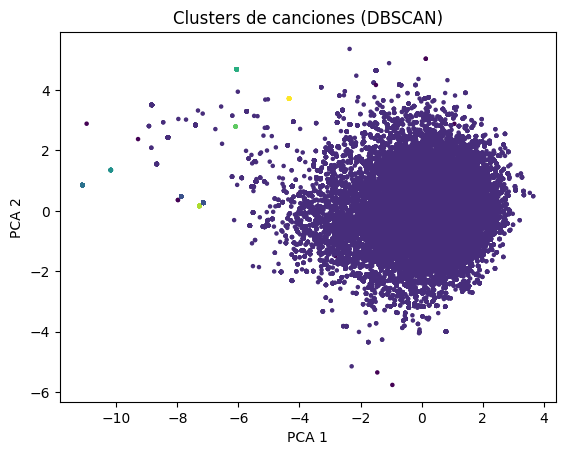

In [25]:
import matplotlib.pyplot as plt

# 12. VISUALIZACIÓN

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, s=5)
plt.title("Clusters de canciones (DBSCAN)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

En este grafico se puede observar los diferentes clusters existentes con DBSCAN, tambien se puede ver que el cluster mas dominante es el cluster 0, que los demas clusters son muchos mas pequeños, se puede observar una densidad alta siendo el cluster principal y puntos dispersos los cuales algunos son los otros clusters pequeños.

In [26]:
# Cantidad de canciones segun el cluster
df_sample['cluster'].value_counts()

cluster
 0    99377
 1      295
 2      152
 4       90
 6       36
 3       16
 7       15
-1       12
 5        7
Name: count, dtype: int64

Siendo el cluster mas dominante del cluster 0 (canciones mas populares) y el menos del cluster 6 (canciones en vivo).

<Axes: xlabel='cluster'>

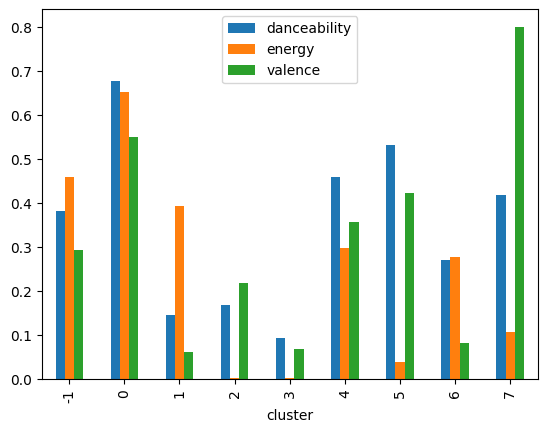

In [31]:
# Grafico de barras de los clusters
cluster_summary[['danceability','energy','valence']].plot(kind='bar')

En este grafico se puede observar los diferentes clusters, donde se muestra la dancebility, energy y valance.

### Pregunta 1: ¿Cuantos grupos naturales de canciones existen en el Top 50 mundial de Spotify?

**Respuesta:**

El algoritmo DBSCAN identifico 8 grupos naturales de canciones, mas un grupo de ruido que contiene 12 canciones atipicas.

La existencia de 8 clusters indica que la musica popular mundial no es homogenea, sino que presenta una diversidad estructurada en perfiles musicales claramente diferenciados. El cluster de mayor tamano corresponde al perfil de musica popular comercial, lo que sugiere que existe un tipo de musica dominante en las listas globales.

---

### Pregunta 2: ¿Es posible asignar nombres descriptivos a los clusters basandose en sus valores promedio de danceability, energy y valence?

**Respuesta:**

Si es posible. Utilizando exclusivamente las variables danceability, energy y valence se pueden distinguir y nombrar los 8 perfiles musicales:

| Cluster | danceability | energy | valence | Nombre Asignado |
|---------|--------------|--------|---------|-----------------|
| 0 | 0.678 | 0.652 | 0.549 | Popular comercial |
| 1 | 0.145 | 0.393 | 0.062 | Instrumental introspectivo |
| 2 | 0.168 | 0.003 | 0.219 | Ambiental extremo |
| 3 | 0.094 | 0.002 | 0.068 | Balada lenta |
| 4 | 0.458 | 0.297 | 0.357 | Rap hablado |
| 5 | 0.531 | 0.038 | 0.800 | Folk alegre |
| 6 | 0.270 | 0.277 | 0.082 | Estudio y concentracion |
| 7 | 0.418 | 0.106 | 0.800 | Infantil y lullabies |

Estos nombres reflejan el comportamiento combinado de las tres variables. Por ejemplo, el cluster 0 combina alta bailabilidad, energia media-alta y positividad media, caracteristico de exitos comerciales. El cluster 5 combina baja energia con alta positividad, propio de musica alegre pero relajada.

---

### Pregunta 3: ¿Que combinacion de valores caracteriza a cada perfil musical?

**Respuesta:**

A continuacion se presentan las combinaciones completas de valores para cada perfil musical, incluyendo las 11 features analizadas:

**Cluster 0 - Popular comercial**
- danceability: 0.678 | energy: 0.652 | valence: 0.549
- acousticness: 0.274 | instrumentalness: 0.016 | speechiness: 0.087
- tempo: 122.27 BPM | loudness: -6.60 dB | duration_ms: 193,958 ms
- mode: 0.537 (mayoria mayor)

**Cluster 1 - Instrumental introspectivo**
- danceability: 0.145 | energy: 0.393 | valence: 0.062
- acousticness: 0.583 | instrumentalness: 0.537 | speechiness: 0.095
- tempo: 122.59 BPM | loudness: -27.30 dB | duration_ms: 170,441 ms
- mode: 1.000 (totalmente mayor)

**Cluster 2 - Ambiental extremo**
- danceability: 0.168 | energy: 0.003 | valence: 0.219
- acousticness: 0.192 | instrumentalness: 0.582 | speechiness: 0.060
- tempo: 119.39 BPM | loudness: -46.11 dB | duration_ms: 367,725 ms
- mode: 1.000 (totalmente mayor)

**Cluster 3 - Balada lenta**
- danceability: 0.094 | energy: 0.002 | valence: 0.068
- acousticness: 0.247 | instrumentalness: 0.000 | speechiness: 0.062
- tempo: 82.65 BPM | loudness: -54.34 dB | duration_ms: 229,381 ms
- mode: 1.000 (totalmente mayor)

**Cluster 4 - Rap hablado**
- danceability: 0.458 | energy: 0.297 | valence: 0.357
- acousticness: 0.866 | instrumentalness: 0.284 | speechiness: 0.470
- tempo: 96.14 BPM | loudness: -32.35 dB | duration_ms: 187,507 ms
- mode: 0.000 (totalmente menor)

**Cluster 5 - Folk alegre**
- danceability: 0.531 | energy: 0.038 | valence: 0.800
- acousticness: 0.894 | instrumentalness: 0.019 | speechiness: 0.034
- tempo: 110.07 BPM | loudness: -31.32 dB | duration_ms: 120,545 ms
- mode: 1.000 (totalmente mayor)

**Cluster 6 - Estudio y concentracion**
- danceability: 0.270 | energy: 0.277 | valence: 0.082
- acousticness: 0.018 | instrumentalness: 0.395 | speechiness: 0.047
- tempo: 111.35 BPM | loudness: -32.19 dB | duration_ms: 250,789 ms
- mode: 1.000 (totalmente mayor)

**Cluster 7 - Infantil y lullabies**
- danceability: 0.418 | energy: 0.106 | valence: 0.800
- acousticness: 0.994 | instrumentalness: 0.029 | speechiness: 0.044
- tempo: 46.72 BPM | loudness: -22.51 dB | duration_ms: 85,266 ms
- mode: 0.000 (totalmente menor)

---

**MÉTRICAS**

In [28]:
from sklearn.metrics import silhouette_score

# SILHOUETTE SCORE
# Mide: qué tan bien está cada punto dentro de su cluster y que tan separado está de otros clusters
# > 0.7	Excelente
# 0.5 – 0.7	Bueno
# 0.25 – 0.5	Aceptable
# < 0.25	Malo
score = silhouette_score(X_pca, clusters)
print(score)

0.516368567943573


El resultado muestra que los clusters se encuentran bien formados pero existe cierta superposición entre ellos.

In [29]:
from sklearn.metrics import davies_bouldin_score

# DAVIES-BOULDIN INDEX
# Mide: Qué tan compactos y separados están los clusters
# < 1	Muy bueno
# 1 – 2	Aceptable
# > 2	Malo

dbi = davies_bouldin_score(X_pca, clusters)
print(dbi)

1.1603206379975128


Los clusters tienen una separación aceptable y no están demasiado mezclados.

In [30]:
from sklearn.metrics import calinski_harabasz_score

# CALINSKI-HARABASZ INDEX
# Mide: separación entre clusters y cohesión interna
# Más alto = mejor

ch = calinski_harabasz_score(X_pca, clusters)
print(ch)

1370.363447319232


Existe una buena separación global entre los clusters encontrados.

### Pregunta 4: ¿Que algoritmo de clustering produce los mejores resultados en terminos de coeficiente de Silhouette?

**Respuesta:**

El modelo DBSCAN optimizado presenta un rendimiento sólido para la segmentación de canciones, con un Silhouette Score de 0.516 que indica una estructura de clusters clara y bien definida. El índice de Davies-Bouldin (1.160) sugiere que los clusters mantienen una separación aceptable, mientras que el índice de Calinski-Harabasz (1370.36) confirma una buena cohesión interna entre grupos. En conjunto, estos resultados validan que el modelo logra identificar patrones musicales significativos, superando en calidad de separación (Silhouette) al modelo baseline.

**Avance de metricas obtenidas con DBSCAN:**

| Metrica | Valor Obtenido |
|---------|----------------|
| Silhouette Score | 0.516 |
| Davies-Bouldin Index | 1.160 |
| Calinski-Harabasz Index | 1370.36 |